In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [4]:
list_AC_stark_vals=[np.float64(-0.06854670085965597), np.float64(-0.0791553748461747), np.float64(-0.09052059521500729), np.float64(-0.10284236196615382), np.float64(-0.11592067509961422), np.float64(-0.12985553461538857), np.float64(-0.14474694051347667), np.float64(-0.16039489279387883), np.float64(-0.17729939145659485), np.float64(-0.19496043650162476), np.float64(-0.21367802792896848), np.float64(-0.2334521657386262), np.float64(-0.2542828499305977), np.float64(-0.2759700805048832), np.float64(-0.2989138574614825), np.float64(-0.3229141808003959), np.float64(-0.34777105052162305), np.float64(-0.373784466625164), np.float64(-0.40095442911101903), np.float64(-0.4288809379791878)]
list_AC_stark_ef_vals=[np.float64(0.5765948637445237), np.float64(0.557319407181995), np.float64(0.5387388599397027), np.float64(0.5148532220176467), np.float64(0.4966624934158271), np.float64(0.4891666741342439), np.float64(0.46036576417289726), np.float64(0.3852597635317868), np.float64(0.39984867221091297), np.float64(0.3701324902102753), np.float64(0.34311121752987417), np.float64(0.31778485416970953), np.float64(0.2941534001297812), np.float64(0.2772168554100892), np.float64(0.2499752200106336), np.float64(0.2244284939314144), np.float64(0.19957667717243177), np.float64(0.1714197697336854), np.float64(0.18795777161517535), np.float64(0.1561906828169018)]


## Simulaatio

In [5]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [6]:
def sim_pulse(f_d,f_supp,A,evolution,dim,f_rabi,K=20,t_ramp=5,verbose=False,p=1):
    T_floquet = 2*np.pi/(f_d) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä

    t_gap=np.pi/(f_supp)
    t_ramp_new=t_ramp-t_gap/2

    phi=t_gap*f_d
    
    N_edge1 = int((t_ramp_new*2+t_gap/2)/dt)
    N_edge2 = int((t_ramp_new*2-t_gap/2)/dt)

    N_pulse=int(2*np.pi/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse1 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp_new*2-t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge2,N_pulse,N_edge1],time_unit=dt,offset_input=-phi/2)
    pulse2 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp_new*2+t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge1,N_pulse,N_edge2],time_unit=dt,offset_input=phi/2)

    combined_pulse = pulse1.raw + pulse2.raw
    m = 2*np.abs(np.cos(phi/2))

    if verbose:
        plt.figure()
        plt.plot(pulse1.time_vals,combined_pulse/m)
        plt.plot(pulse1.time_vals,(pulse1.envelope + pulse2.envelope)/2)
        plt.xlabel("Aika (ms)")
        plt.xlim([5,10])
        plt.ylabel("Normalisoitu amplitudi")
        plt.title("Yhdistetty pulssi")
        plt.show()

    U_floquet=evolution.U_floquet(A*combined_pulse[N_edge1:N_edge1+K]/m,dt)
    U_floquet=np.linalg.matrix_power(U_floquet,p)

    #Alustetaan kubitin tila perustilaan
    psi_eig_accum = np.zeros(dim, dtype=complex)
    psi_eig_accum[0] = 1

    #Lopulliset todennäköisyydet eripituisten pulssien jälkeen
    last_vals=[]

    for i in range(0, N_edge1): #Aikakehitys nousevalle rampille
        psi_eig_accum = evolution.U(A*combined_pulse[i]/m, dt) @ psi_eig_accum

    #Simuloitujen pulssien määrä/K koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (K*dt)
    N_sim=int(N_pulse/(K*p))

    #Simulaatio pulsseille
    for k in range(0,N_sim):
        psi_eig = psi_eig_accum

        #Laskevan rampin simulaatio
        pulse1 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp*2-t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge2,K*p*k,N_edge1],time_unit=dt,offset_input=-phi/2)
        pulse2 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp*2+t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge1,K*p*k,N_edge2],time_unit=dt,offset_input=phi/2)
        combined_pulse = pulse1.raw + pulse2.raw

        remainder = len(combined_pulse)-N_edge1-K*p*k

        for i in range(0, remainder): #Aikakehitys
            psi_eig = evolution_eigenbasis.U(A*combined_pulse[N_edge1+K*p*k+i]/m, dt) @ psi_eig
        last_vals.append(np.abs(psi_eig)**2)
        psi_eig_accum = U_floquet @ psi_eig_accum #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla


    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([a[1] for a in last_vals])
    f_vals = np.array([a[2] for a in last_vals])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_pulse)*K*p*dt + 2*t_ramp

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    index = np.argmax(e_vals)
    T_pulse = pulse_times[index]
    
    return (excited_max,f_max,T_pulse,last_vals,pulse_times)

def find_params(f_d,f_supp,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]

    for i in range(min_range,max_range):
        delta=AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)

        if A < 8:
            sim_vals = sim_pulse(f_d+delta,f_supp,A,evolution,dim,f_rabi,t_ramp=5,p=5)
        else:
            sim_vals = sim_pulse(f_d+delta,f_supp,A,evolution,dim,f_rabi,t_ramp=5)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_ef-ω_suppressed (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

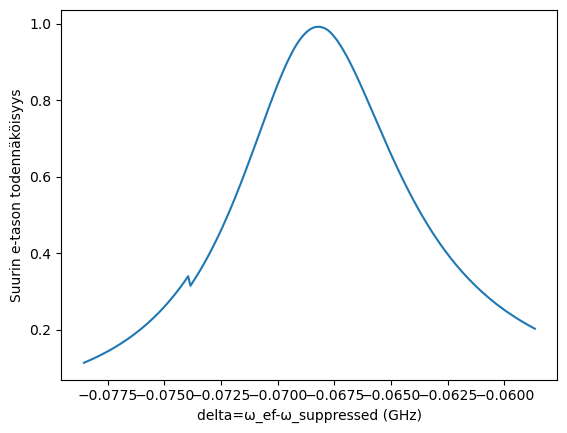

Amplitudi (GHz): 5.862378319586982
AC-stark siirtymä (GHz): -0.06824670085965598
E-tason suurin todennäköisyys: 0.9922308256589015
Pulssin pituus (ns): 252.29312148880337
Rabi-taajuus (fourier):  0.002185626980901045


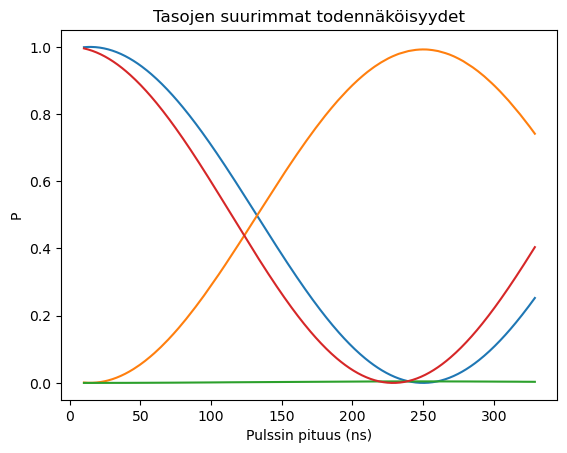

---------------------------------------------


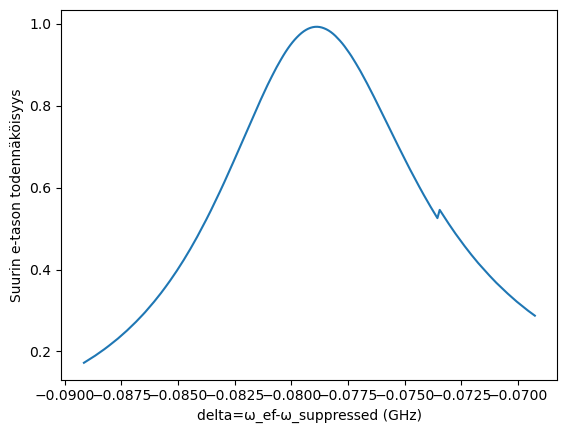

Amplitudi (GHz): 6.291660027199759
AC-stark siirtymä (GHz): -0.0788553748461747
E-tason suurin todennäköisyys: 0.9930701741237938
Pulssin pituus (ns): 211.54336256117583
Rabi-taajuus (fourier):  0.002458847498042732


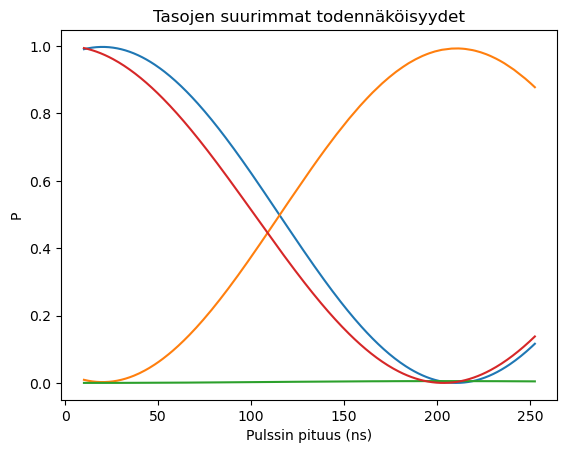

---------------------------------------------


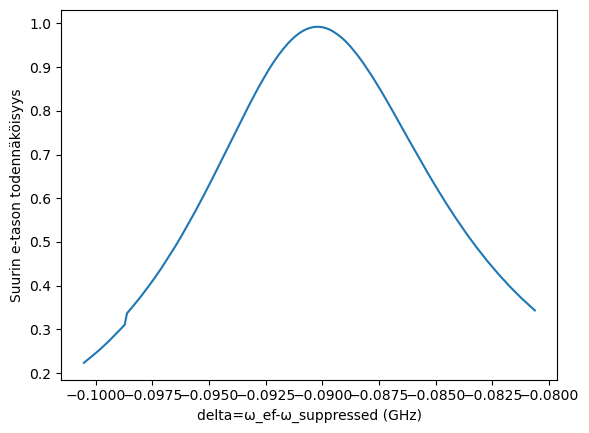

Amplitudi (GHz): 6.720941734812535
AC-stark siirtymä (GHz): -0.09022059521500729
E-tason suurin todennäköisyys: 0.9923281940623621
Pulssin pituus (ns): 174.44255033837845
Rabi-taajuus (fourier):  0.0030944947899365985


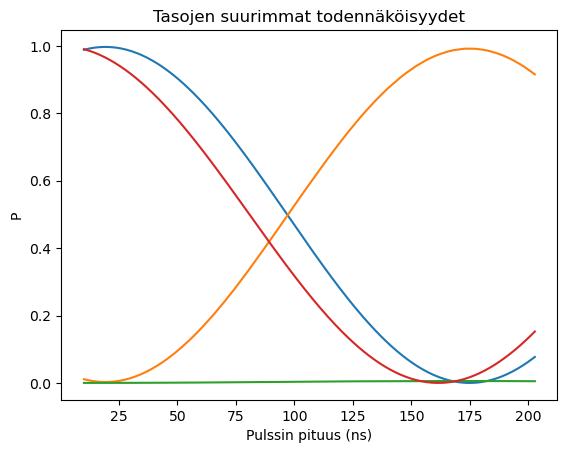

---------------------------------------------


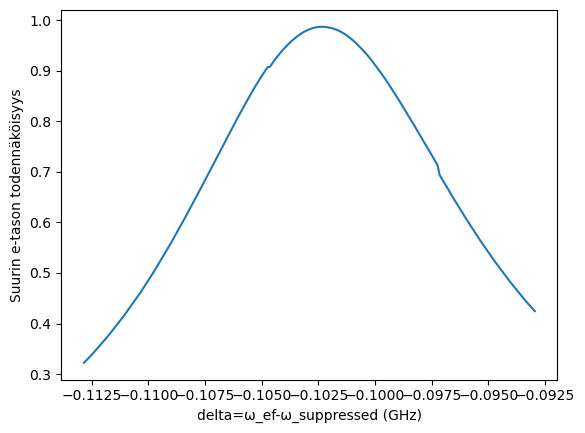

Amplitudi (GHz): 7.150223442425313
AC-stark siirtymä (GHz): -0.10234236196615382
E-tason suurin todennäköisyys: 0.9874822159247064
Pulssin pituus (ns): 148.48093067734578


Rabi-taajuus (fourier):  0.0037934425227216404


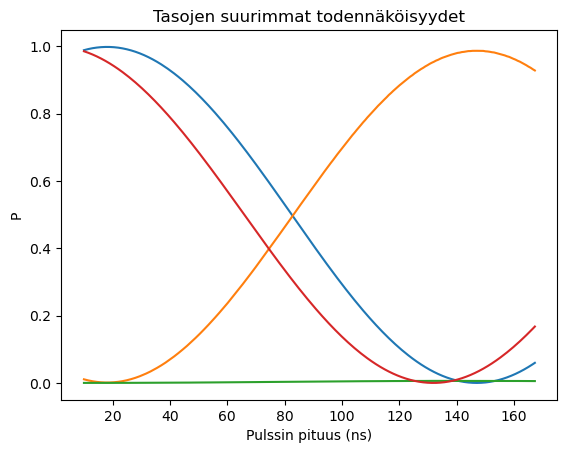

---------------------------------------------


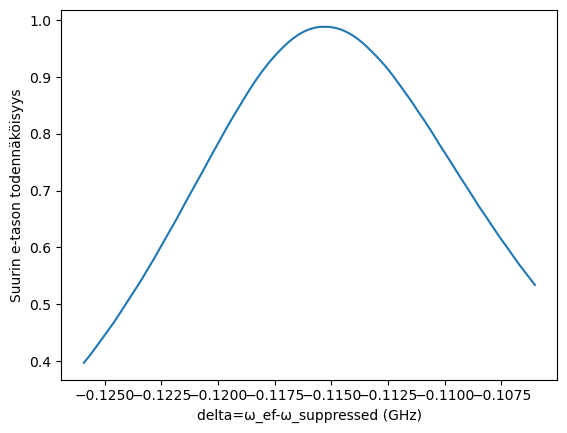

Amplitudi (GHz): 7.57950515003809
AC-stark siirtymä (GHz): -0.11532067509961422
E-tason suurin todennäköisyys: 0.9896018836998084
Pulssin pituus (ns): 129.95275848960145
Rabi-taajuus (fourier):  0.004570617175546377


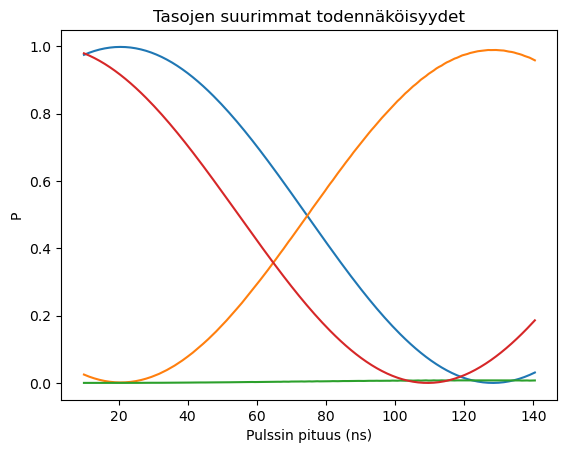

---------------------------------------------


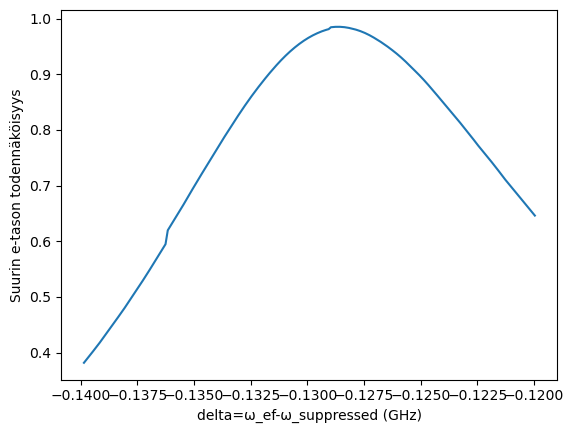

Amplitudi (GHz): 8.008786857650867
AC-stark siirtymä (GHz): -0.12865553461538856
E-tason suurin todennäköisyys: 0.9853581361347921
Pulssin pituus (ns): 109.86963356518021
Rabi-taajuus (fourier):  0.005435657701726179


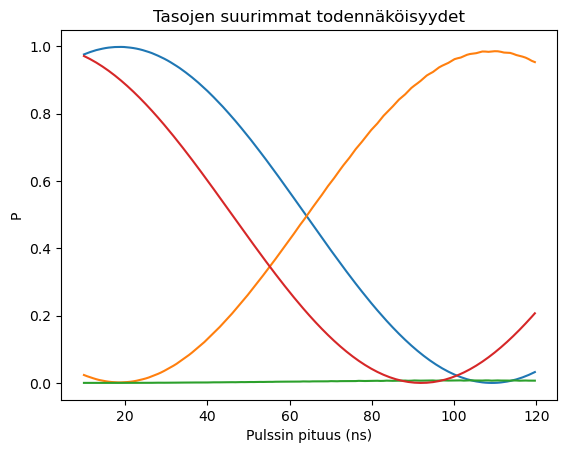

---------------------------------------------


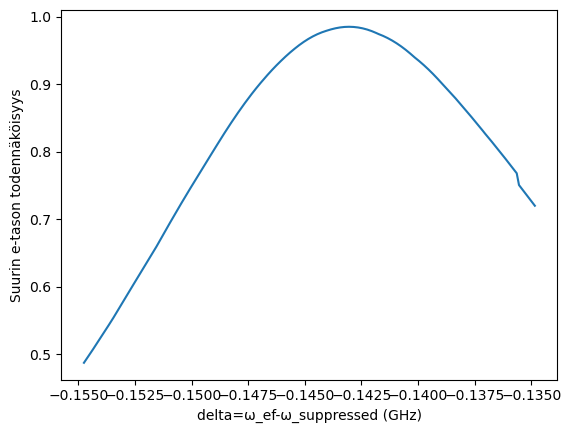

Amplitudi (GHz): 8.438068565263642
AC-stark siirtymä (GHz): -0.14304694051347666
E-tason suurin todennäköisyys: 0.9849161758923204
Pulssin pituus (ns): 95.7500251941635
Rabi-taajuus (fourier):  0.006401825073207981


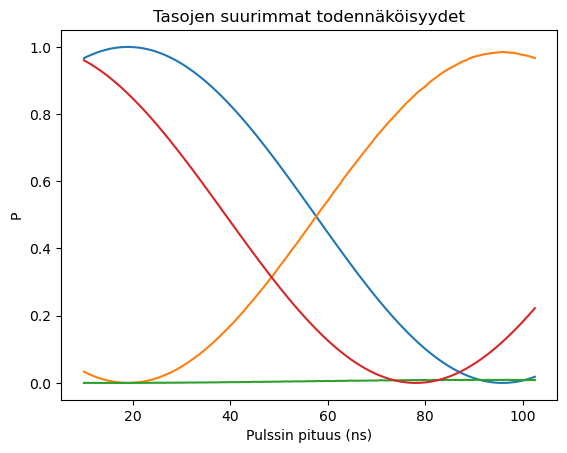

---------------------------------------------


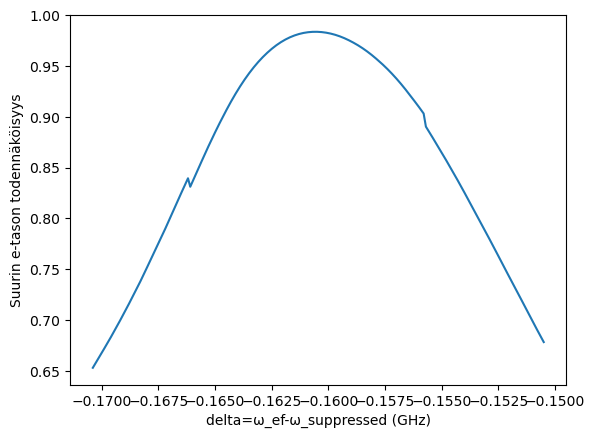

Amplitudi (GHz): 8.86735027287642
AC-stark siirtymä (GHz): -0.16059489279387884
E-tason suurin todennäköisyys: 0.9845546222022052
Pulssin pituus (ns): 84.6238938681867
Rabi-taajuus (fourier):  0.007488162729198257


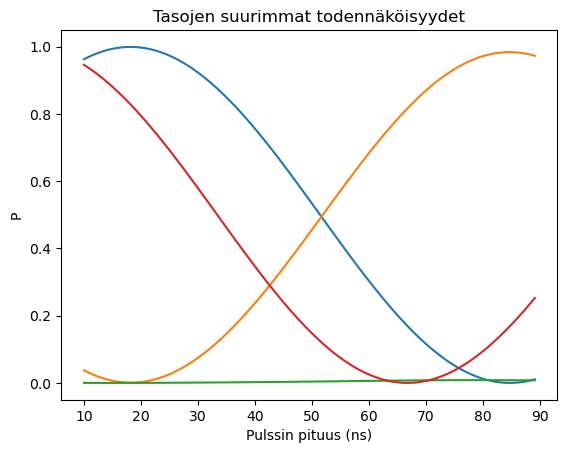

---------------------------------------------


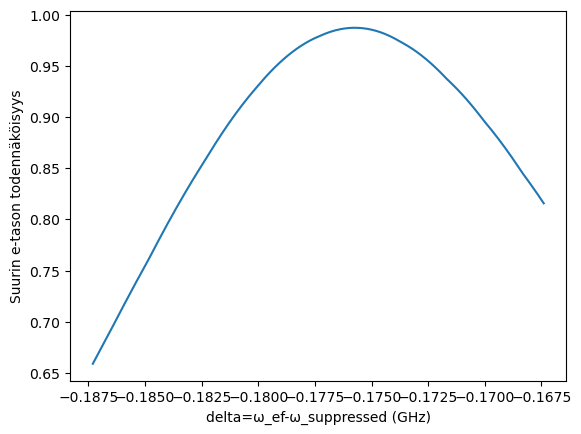

Amplitudi (GHz): 9.296631980489197
AC-stark siirtymä (GHz): -0.17569939145659486
E-tason suurin todennäköisyys: 0.9877884085372215
Pulssin pituus (ns): 73.43218530400713
Rabi-taajuus (fourier):  0.008702621300533585


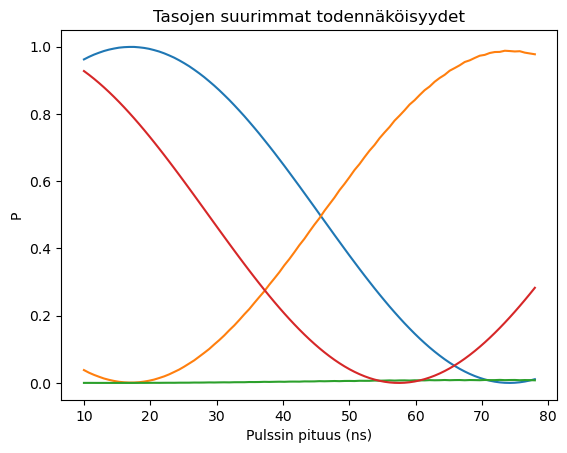

---------------------------------------------


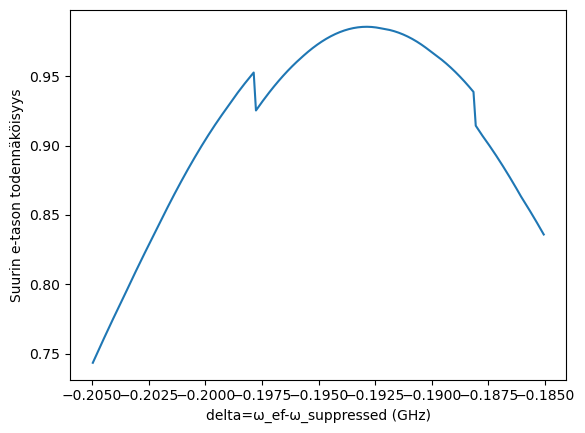

Amplitudi (GHz): 9.725913688101974
AC-stark siirtymä (GHz): -0.19286043650162477
E-tason suurin todennäköisyys: 0.9856895412414158
Pulssin pituus (ns): 66.75293273851085
Rabi-taajuus (fourier):  0.010062316822972005


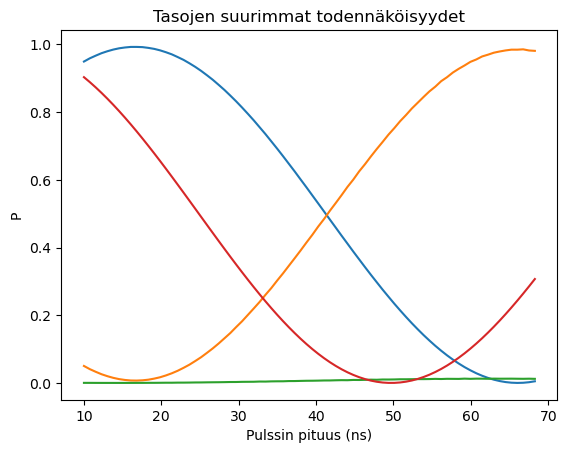

---------------------------------------------


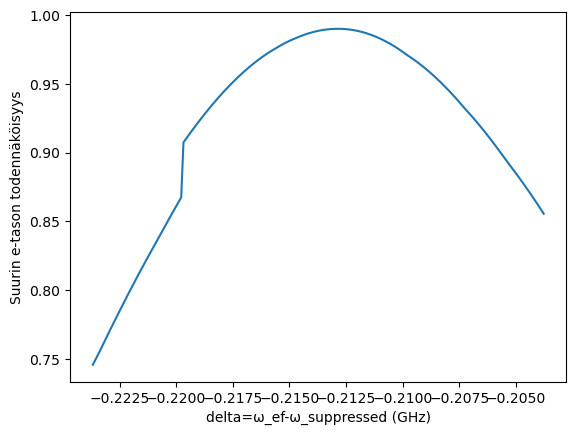

Amplitudi (GHz): 10.15519539571475
AC-stark siirtymä (GHz): -0.21287802792896848
E-tason suurin todennäköisyys: 0.9900386392074483
Pulssin pituus (ns): 58.546203869681285
Rabi-taajuus (fourier):  0.011564313252566065


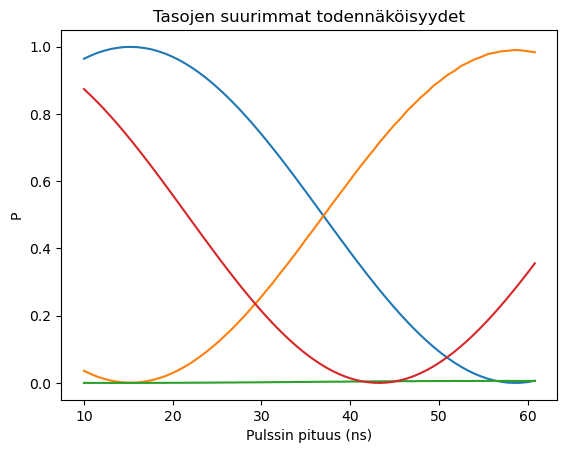

---------------------------------------------


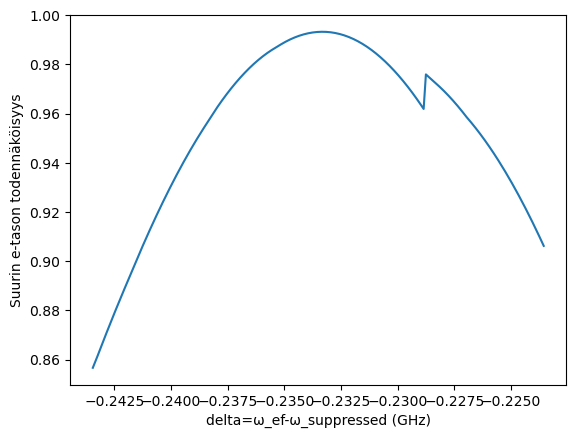

Amplitudi (GHz): 10.584477103327528
AC-stark siirtymä (GHz): -0.23335216573862622
E-tason suurin todennäköisyys: 0.9932389257884813
Pulssin pituus (ns): 52.583182522116104
Rabi-taajuus (fourier):  0.013238991448536052


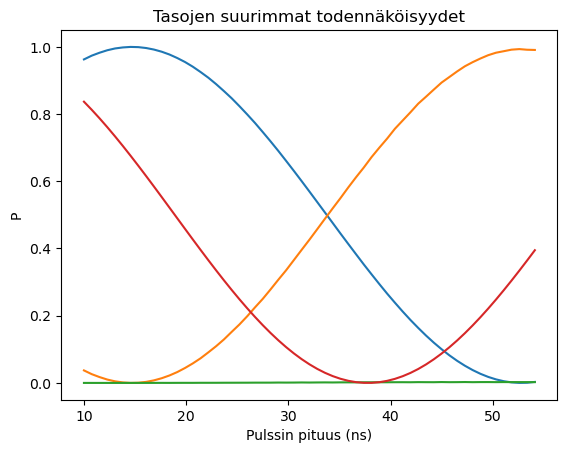

---------------------------------------------


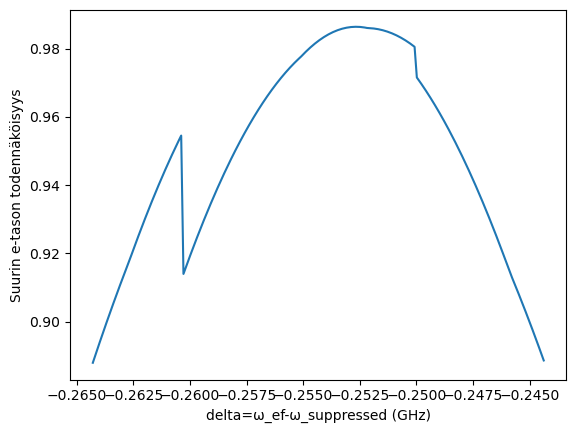

Amplitudi (GHz): 11.013758810940303
AC-stark siirtymä (GHz): -0.2526828499305977
E-tason suurin todennäköisyys: 0.9884273304591189
Pulssin pituus (ns): 48.87205264795384


Rabi-taajuus (fourier):  0.015109365565590178


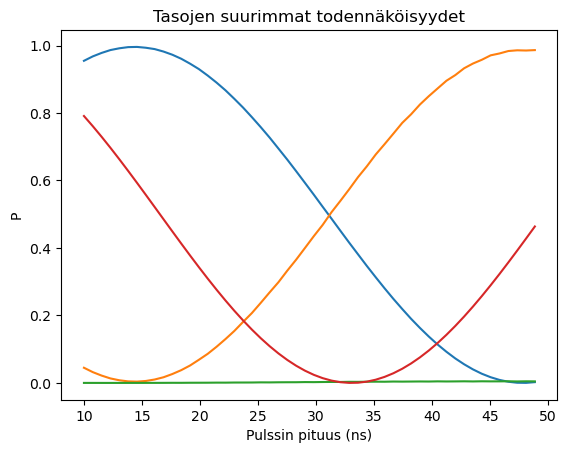

---------------------------------------------


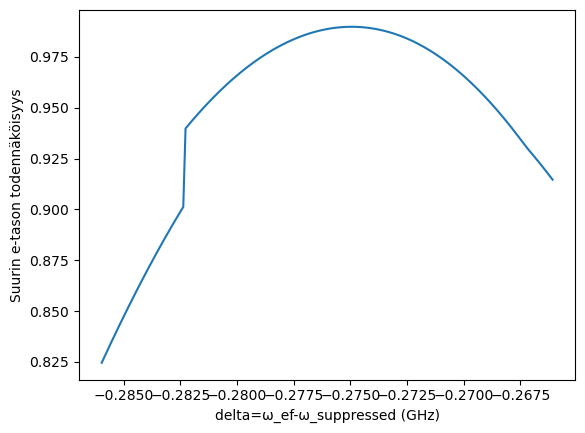

Amplitudi (GHz): 11.44304051855308
AC-stark siirtymä (GHz): -0.2749700805048832
E-tason suurin todennäköisyys: 0.9926346169565203
Pulssin pituus (ns): 43.62758865131035
Rabi-taajuus (fourier):  0.01714125921875574


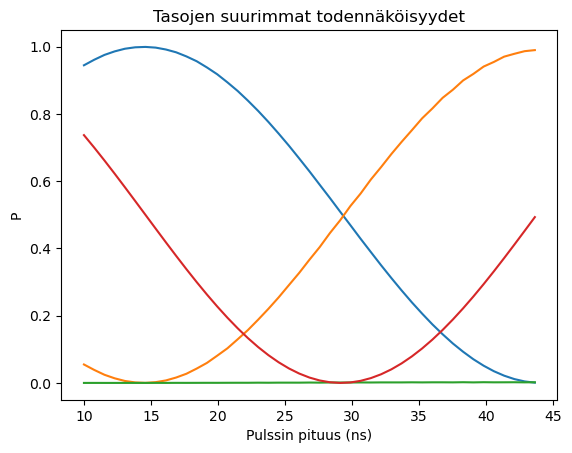

---------------------------------------------


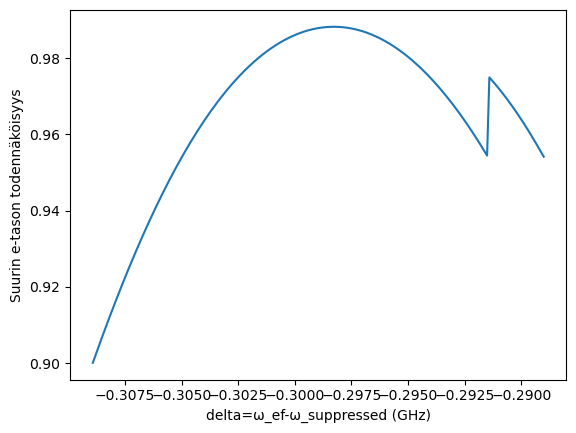

Amplitudi (GHz): 11.872322226165856
AC-stark siirtymä (GHz): -0.29831385746148253
E-tason suurin todennäköisyys: 0.9934740406748996
Pulssin pituus (ns): 39.89114618996847
Rabi-taajuus (fourier):  0.019425322722659216


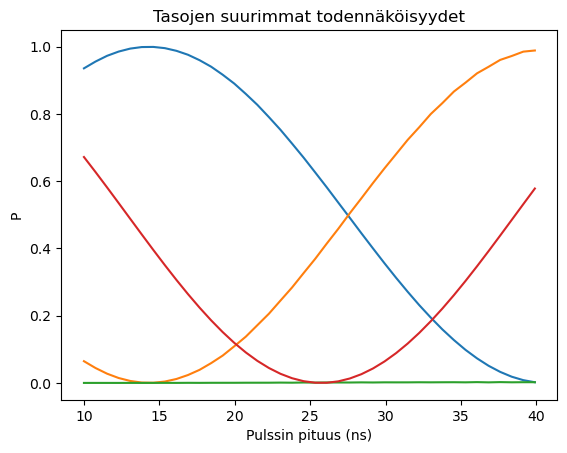

---------------------------------------------


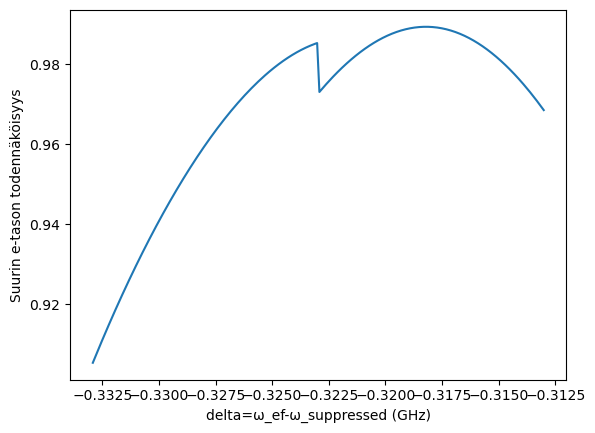

Amplitudi (GHz): 12.301603933778635
AC-stark siirtymä (GHz): -0.31821418080039593
E-tason suurin todennäköisyys: 0.9914839447696812
Pulssin pituus (ns): 36.12235984115864
Rabi-taajuus (fourier):  0.0218750746449876


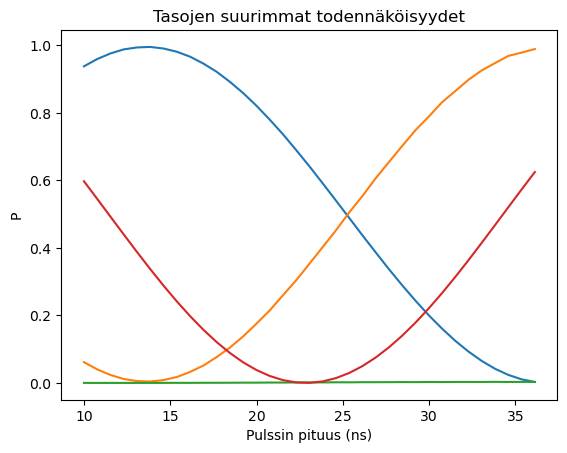

---------------------------------------------


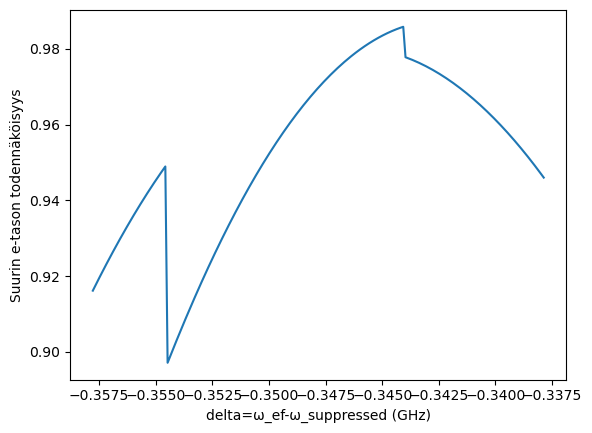

Amplitudi (GHz): 12.730885641391412
AC-stark siirtymä (GHz): -0.34407105052162307
E-tason suurin todennäköisyys: 0.9896731849774134
Pulssin pituus (ns): 33.12224814818805
Rabi-taajuus (fourier):  0.024635158723058454


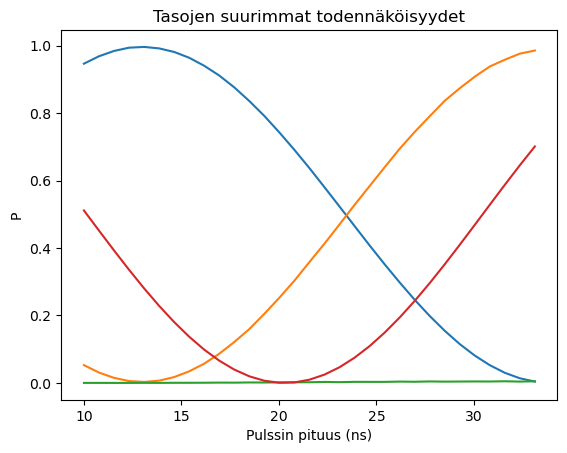

---------------------------------------------


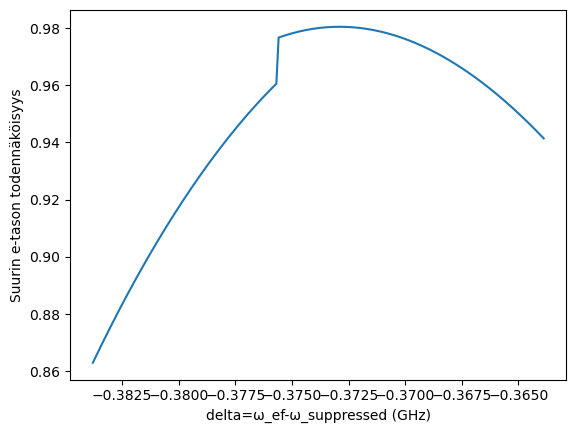

Amplitudi (GHz): 13.160167349004187
AC-stark siirtymä (GHz): -0.372884466625164
E-tason suurin todennäköisyys: 0.9945907766944944
Pulssin pituus (ns): 30.8838365226732
Rabi-taajuus (fourier):  0.02760567747645911


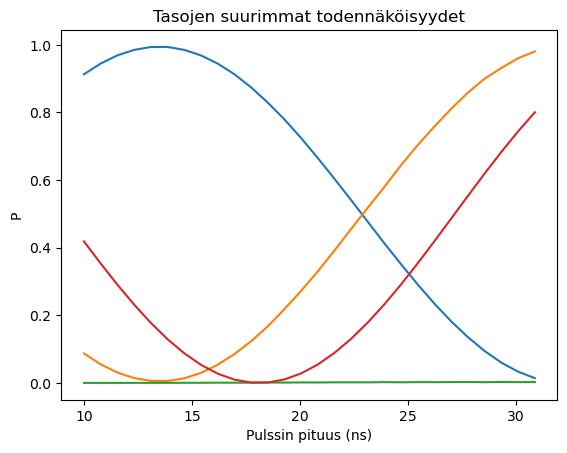

---------------------------------------------


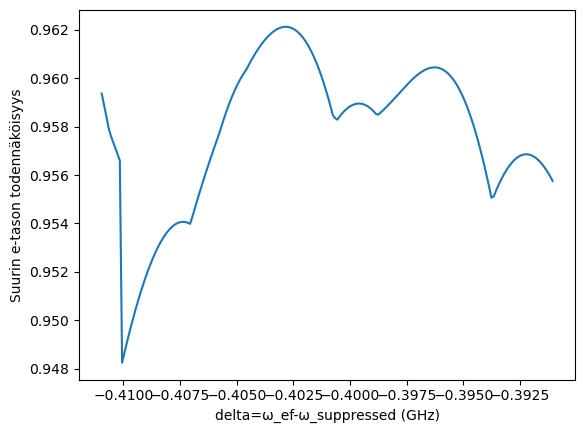

Amplitudi (GHz): 13.589449056616964
AC-stark siirtymä (GHz): -0.40285442911101904
E-tason suurin todennäköisyys: 0.9664290777938765
Pulssin pituus (ns): 23.97411343260191
Rabi-taajuus (fourier):  0.030791140098970535


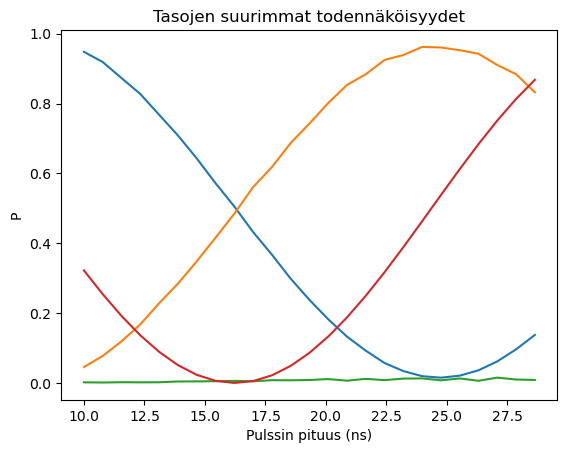

---------------------------------------------


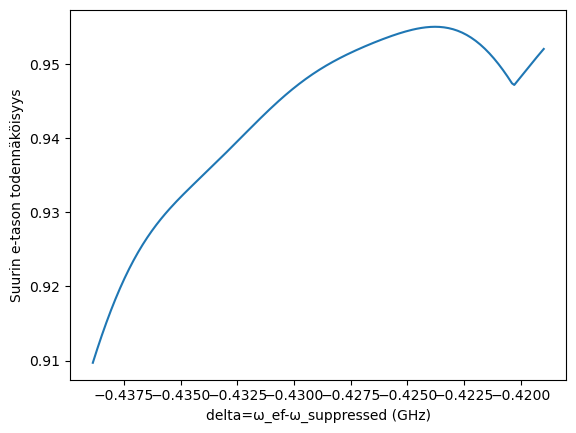

Amplitudi (GHz): 14.01873076422974
AC-stark siirtymä (GHz): -0.4237809379791878
E-tason suurin todennäköisyys: 0.9569935702186324
Pulssin pituus (ns): 24.01033917728225
Rabi-taajuus (fourier):  0.03426041253721535


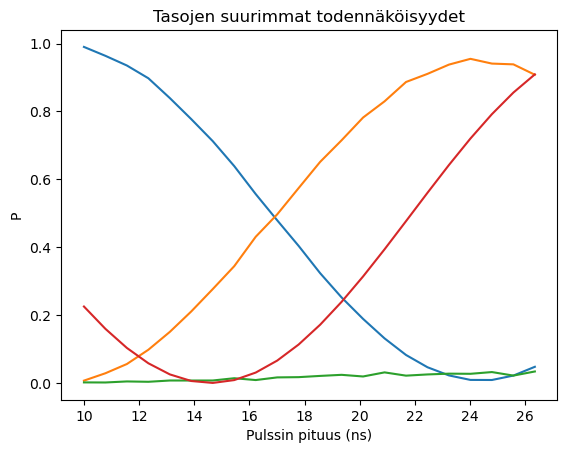

---------------------------------------------


In [7]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.23
max_range = 0.55
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_d = qubit.frequency/3
    f_supp_opt = f_ef/3+list_AC_stark_ef_vals[i]

    f_rabi=2.875e-05*A**3 - 0.0003995*A**2 + 0.003097*A - 0.008257 #Arvaus Rabi-taajuudelle
    AC_stark=list_AC_stark_vals[i] #Arvaus AC-stark siirtymälle

    params=find_params(f_d, f_supp_opt, A, evolution_eigenbasis,f_rabi*10,AC_stark,[-100,100],10000)

    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    f_d_opt = f_d+deltas[-1]

    m=10
    vals = sim_pulse(f_d_opt,f_supp_opt,A,evolution_eigenbasis,dim,(f_rabi*10)/m,t_ramp=5)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])
    
    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(5.862378319586982), np.float64(6.291660027199759), np.float64(6.720941734812535), np.float64(7.150223442425313), np.float64(7.57950515003809), np.float64(8.008786857650867), np.float64(8.438068565263642), np.float64(8.86735027287642), np.float64(9.296631980489197), np.float64(9.725913688101974), np.float64(10.15519539571475), np.float64(10.584477103327528), np.float64(11.013758810940303), np.float64(11.44304051855308), np.float64(11.872322226165856), np.float64(12.301603933778635), np.float64(12.730885641391412), np.float64(13.160167349004187), np.float64(13.589449056616964), np.float64(14.01873076422974)]


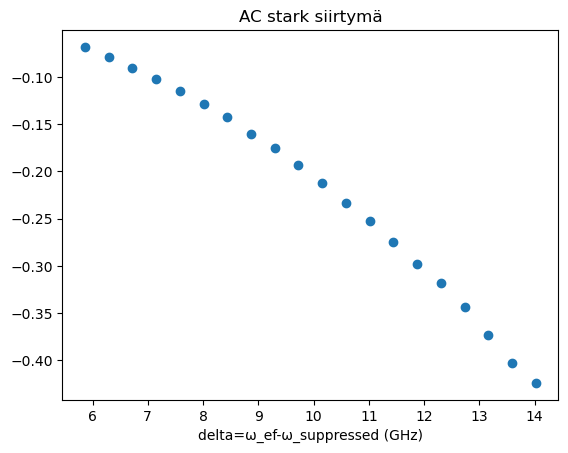

[np.float64(-0.06824670085965598), np.float64(-0.0788553748461747), np.float64(-0.09022059521500729), np.float64(-0.10234236196615382), np.float64(-0.11532067509961422), np.float64(-0.12865553461538856), np.float64(-0.14304694051347666), np.float64(-0.16059489279387884), np.float64(-0.17569939145659486), np.float64(-0.19286043650162477), np.float64(-0.21287802792896848), np.float64(-0.23335216573862622), np.float64(-0.2526828499305977), np.float64(-0.2749700805048832), np.float64(-0.29831385746148253), np.float64(-0.31821418080039593), np.float64(-0.34407105052162307), np.float64(-0.372884466625164), np.float64(-0.40285442911101904), np.float64(-0.4237809379791878)]


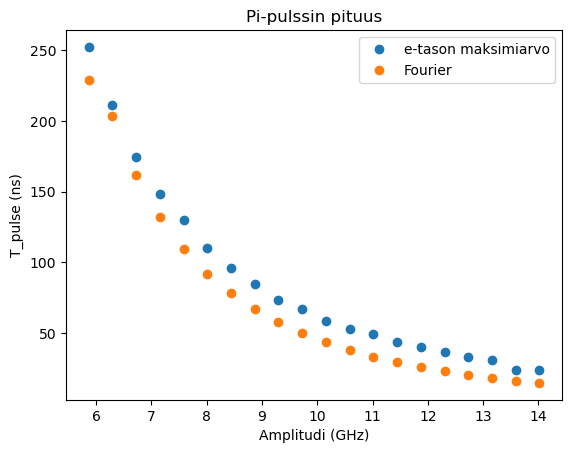

[np.float64(252.29312148880337), np.float64(211.54336256117583), np.float64(174.44255033837845), np.float64(148.48093067734578), np.float64(129.95275848960145), np.float64(109.86963356518021), np.float64(95.7500251941635), np.float64(84.6238938681867), np.float64(73.43218530400713), np.float64(66.75293273851085), np.float64(58.546203869681285), np.float64(52.583182522116104), np.float64(48.87205264795384), np.float64(43.62758865131035), np.float64(39.89114618996847), np.float64(36.12235984115864), np.float64(33.12224814818805), np.float64(30.8838365226732), np.float64(23.97411343260191), np.float64(24.01033917728225)]


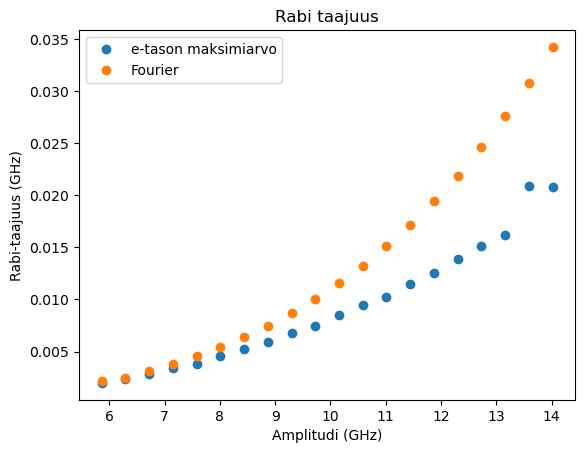

[np.float64(0.002185626980901045), np.float64(0.002458847498042732), np.float64(0.0030944947899365985), np.float64(0.0037934425227216404), np.float64(0.004570617175546377), np.float64(0.005435657701726179), np.float64(0.006401825073207981), np.float64(0.007488162729198257), np.float64(0.008702621300533585), np.float64(0.010062316822972005), np.float64(0.011564313252566065), np.float64(0.013238991448536052), np.float64(0.015109365565590178), np.float64(0.01714125921875574), np.float64(0.019425322722659216), np.float64(0.0218750746449876), np.float64(0.024635158723058454), np.float64(0.02760567747645911), np.float64(0.030791140098970535), np.float64(0.03426041253721535)]


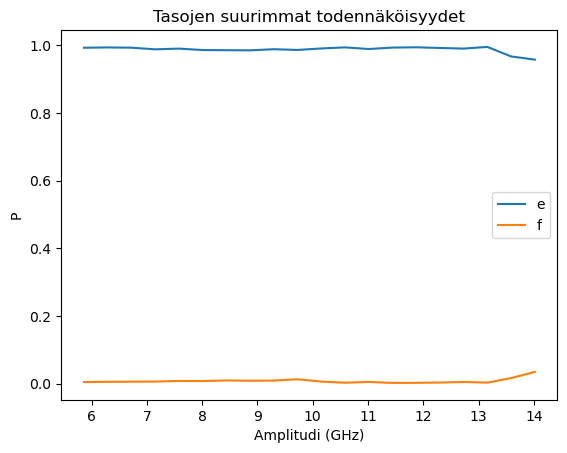

[np.float64(0.9922308256589015), np.float64(0.9930701741237938), np.float64(0.9923281940623621), np.float64(0.9874822159247064), np.float64(0.9896018836998084), np.float64(0.9853581361347921), np.float64(0.9849161758923204), np.float64(0.9845546222022052), np.float64(0.9877884085372215), np.float64(0.9856895412414158), np.float64(0.9900386392074483), np.float64(0.9932389257884813), np.float64(0.9884273304591189), np.float64(0.9926346169565203), np.float64(0.9934740406748996), np.float64(0.9914839447696812), np.float64(0.9896731849774134), np.float64(0.9945907766944944), np.float64(0.9664290777938765), np.float64(0.9569935702186324)]
[np.float64(0.00459134391893767), np.float64(0.005451463295870342), np.float64(0.00577992570396861), np.float64(0.006155101676034763), np.float64(0.00787323779971538), np.float64(0.0076364758721838046), np.float64(0.00944985619440986), np.float64(0.008543406333799483), np.float64(0.008987837888146251), np.float64(0.01288716110599748), np.float64(0.006143010

In [8]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.xlabel("delta=ω_ef-ω_suppressed (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.plot(A_vals, 1/(2*np.array(rabis)), 'o')
plt.legend(["e-tason maksimiarvo","Fourier"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, 1/(2*np.array(pulse_lengths)), 'o')
plt.plot(A_vals, rabis, 'o')
plt.legend(["e-tason maksimiarvo","Fourier"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(A_vals, e_vals)
plt.plot(A_vals, f_vals)
plt.legend(["e","f"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

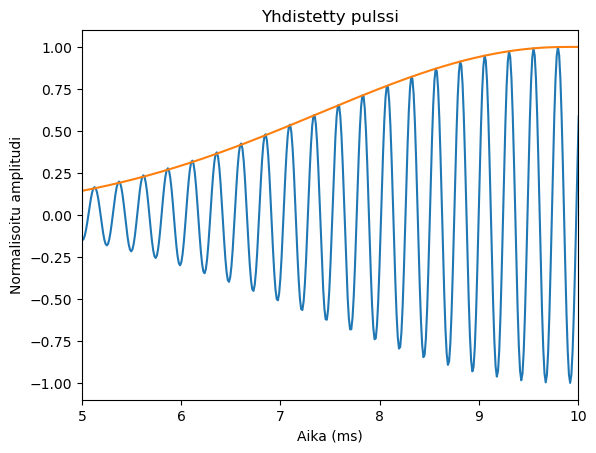

0.9989059444513094 2.5442406204682882e-08 21.585951889811938


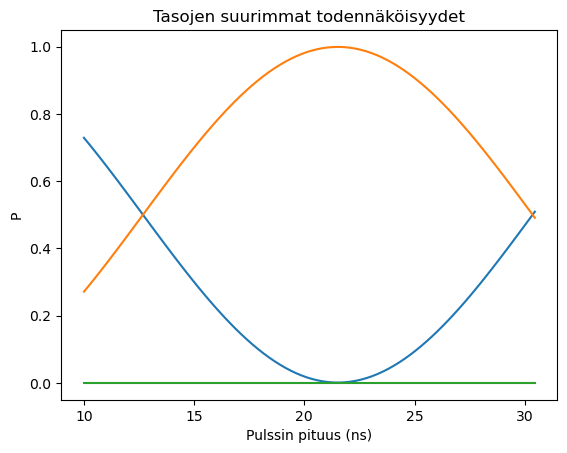

---------------------------------------------


In [9]:
A=0.17842020972626485
f_d=qubit.frequency
vals = sim_pulse(f_d,f_ef-0.09280978620978153,A,evolution_eigenbasis,dim,0.3,t_ramp=5,p=1,verbose=True)
print(vals[0],vals[1],vals[2])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

m=1
n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.plot(vals[4][:n_picked], g_vals[:n_picked])
plt.plot(vals[4][:n_picked], e_vals[:n_picked])
plt.plot(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")